## Train/Test Data Sets

### Evaluate Your Model
In Machine Learning we create models to predict the outcome of certain events, like in the previous chapter where we predicted the CO2 emission of a car when we knew the weight and engine size.

To measure if the model is good enough, we can use a method called Train/Test.

### What is Train/Test
Train/Test is a method to measure the accuracy of your model.

It is called Train/Test because you split the data set into two sets: a training set and a testing set.

80% for training, and 20% for testing.

You train the model using the training set.

You test the model using the testing set.

Train the model means create the model.

Test the model means test the accuracy of the model.

### Start With a Data Set
Start with a data set you want to test.

Our data set illustrates 100 customers in a shop, and their shopping habits.

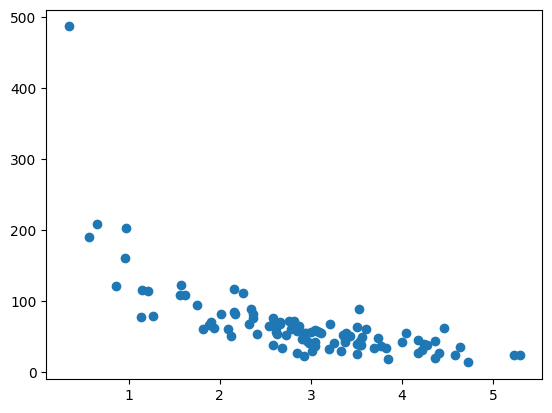

In [1]:
# Example

import numpy
import matplotlib.pyplot as plt
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

plt.scatter(x, y)
plt.show()

### Split into Train and Test
We first create a training set and a testing set from our data.
80% of the data is used for training and 20% for testing.

Train size: 80
Test size: 20


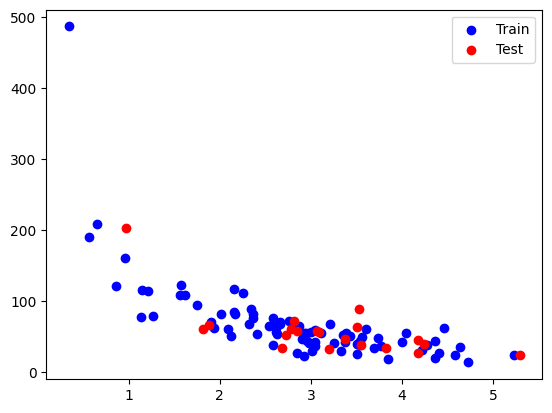

In [2]:
# Split the data into training and testing sets
import numpy
import matplotlib.pyplot as plt
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

# create an index array and shuffle it
indices = numpy.arange(len(x))
numpy.random.shuffle(indices)

# split point for 80% train, 20% test
split_point = int(len(x) * 0.8)

train_indices = indices[:split_point]
test_indices = indices[split_point:]

x_train = x[train_indices]
y_train = y[train_indices]
x_test = x[test_indices]
y_test = y[test_indices]

print("Train size:", len(x_train))
print("Test size:", len(x_test))

plt.scatter(x_train, y_train, color="blue", label="Train")
plt.scatter(x_test, y_test, color="red", label="Test")
plt.legend()
plt.show()

### Fit the Data Set
What does the data set look like? In my opinion I think the best fit would be a polynomial regression, so let us draw a line of polynomial regression.

To draw a line through the data points, we use the plot() method of the matplotlib module:

#### Example
Draw a polynomial regression line through the data points:

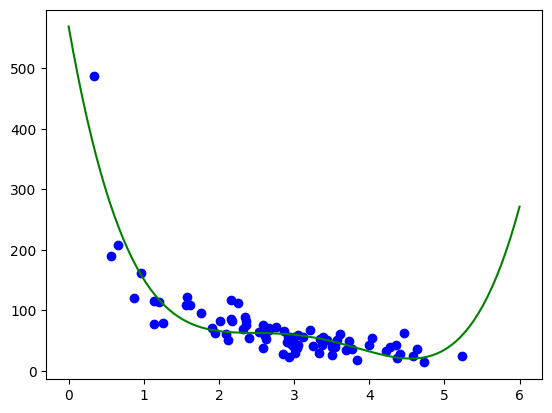

In [3]:
import numpy
import matplotlib.pyplot as plt
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

# create an index array and shuffle it
indices = numpy.arange(len(x))
numpy.random.shuffle(indices)

# split point for 80% train, 20% test
split_point = int(len(x) * 0.8)

train_indices = indices[:split_point]
test_indices = indices[split_point:]

x_train = x[train_indices]
y_train = y[train_indices]
x_test = x[test_indices]
y_test = y[test_indices]

mymodel = numpy.poly1d(numpy.polyfit(x_train, y_train, 4))

myline = numpy.linspace(0, 6, 100)

plt.scatter(x_train, y_train, color="blue", label="Train")
plt.plot(myline, mymodel(myline), color="green", label="Model")
plt.show()

### R2

Remember R2, also known as R-squared?

It measures the relationship between the x axis and the y axis, and the value ranges from 0 to 1, where 0 means no relationship, and 1 means totally related.

The sklearn module has a method called r2_score() that will help us find this relationship.

In this case we would like to measure the relationship between the minutes a customer stays in the shop and how much money they spend.

#### Example
How well does my training data fit in a polynomial regression?

In [4]:
import numpy
from sklearn.metrics import r2_score
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

# create an index array and shuffle it
indices = numpy.arange(len(x))
numpy.random.shuffle(indices)

# split point for 80% train, 20% test
split_point = int(len(x) * 0.8)

train_indices = indices[:split_point]
test_indices = indices[split_point:]

x_train = x[train_indices]
y_train = y[train_indices]
x_test = x[test_indices]
y_test = y[test_indices]

mymodel = numpy.poly1d(numpy.polyfit(x_train, y_train, 4))

r2 = r2_score(y_train, mymodel(x_train))

print(r2)

0.8052129056677164


### Bring in the Testing Set
Now we have made a model that is OK, at least when it comes to training data.

Now we want to test the model with the testing data as well, to see if gives us the same result.

#### Example
Let us find the R2 score when using testing data:

In [6]:
import numpy
from sklearn.metrics import r2_score
numpy.random.seed(2)

x = numpy.random.normal(3, 1, 100)
y = numpy.random.normal(150, 40, 100) / x

# create an index array and shuffle it
indices = numpy.arange(len(x))
numpy.random.shuffle(indices)

# split point for 80% train, 20% test
split_point = int(len(x) * 0.8)

train_indices = indices[:split_point]
test_indices = indices[split_point:]

x_train = x[train_indices]
y_train = y[train_indices]
x_test = x[test_indices]
y_test = y[test_indices]

mymodel = numpy.poly1d(numpy.polyfit(x_train, y_train, 4))

r2_test = r2_score(y_test, mymodel(x_test))

print(r2_test)

0.7029508393828632


### Predict Values
Now that we have established that our model is OK, we can start predicting new values.

#### Example
How much money will a buying customer spend, if she or he stays in the shop for 5 minutes?

In [9]:
print(mymodel(5))

35.00609979521994
